# Mass-spring-damper

Notebook `python/Notebooks/tutorialSpringDamper.ipynb` - the same model with the `Create` functions is
`python/Notebooks/tutorialSpringDamperCreate.ipynb`.

The first tutorial sets up a mass point and a spring-damper, computes the solution dynamically and compares it with
the exact solution. It builds the model from its items - nodes, objects, markers, loads and sensors -, which shows
how Exudyn works inside; the outputs below each cell are those of the last run.

We import the Exudyn library and the items we need:

In [1]:
import exudyn as exu
from exudyn.utilities import Point, NodePointGround, MassPoint, VMassPoint, MarkerNodeCoordinate, \
                             CoordinateSpringDamper, LoadCoordinate, SensorObject, SensorNode
from exudyn.interactive import ShowImage
import exudyn.graphics as graphics
import numpy as np #for postprocessing

Instead of the named import of `exudyn.utilities` functions and classes, you can use a star import,
`from exudyn.utilities import *`, which includes `itemInterface`, `rigidBodyUtilities` and some helper functions.

Next, we need a `SystemContainer`, which contains all computable systems, and add a new MainSystem `mbs`.
Name your system `mbs` (multibody system) always, in order to copy and paste code parts from other examples,
tutorials and projects:

In [2]:
SC = exu.SystemContainer()
mbs = SC.AddSystem()

The version is in line with the issue tracker and counts its resolved issues; `exu.config.Version(True)` adds
platform-specific information, which helps when reporting a compatibility issue:

In [3]:
print('EXUDYN version='+exu.config.Version())

EXUDYN version=1.12.279.dev1


Using the Python language, we define the parameters of our problem, which we will also use for the analytical
solution, and the initial displacement and velocity of the mass:

In [4]:
L = 0.5             #reference position of mass
mass = 1.6          #mass in kg
spring = 4000       #stiffness of spring-damper in N/m
damper = 8          #damping constant in N/(m/s)
f = 80              #force on mass

u0 = -0.08          #initial displacement
v0 = 1              #initial velocity
x0 = f/spring       #static displacement
print('resonance frequency = '+str(np.sqrt(spring/mass)))
print('static displacement = '+str(x0))

resonance frequency = 50.0
static displacement = 0.02


We first need to add **nodes**, which provide the coordinates (and the degrees of freedom) to the system. The
following line adds a 3D node for a 3D mass point; `Point` is an abbreviation of `NodePoint`. Its arguments are
`referenceCoordinates`, the coordinates for which the system is defined; the initial configuration is
`referenceCoordinates + initialCoordinates`, and the initial state additionally gets `initialVelocities`.
`mbs.AddNode(...)` returns a `NodeIndex`, which can only be used as node number - in an object or in a marker.

While `Point` adds 3 unknown coordinates to the system, a **ground node** has no unknown coordinates - and no initial
displacements or velocities; ground nodes (and ground bodies) need no constraints to be fixed:

In [5]:
n1 = mbs.AddNode(Point(referenceCoordinates = [L,0,0],
                       initialCoordinates = [u0,0,0],
                       initialVelocities = [v0,0,0]))
nGround = mbs.AddNode(NodePointGround(referenceCoordinates = [0,0,0]))

Next, an **object**, which provides the equations for the coordinates. Objects depend on one or more nodes - bodies
and finite elements - or connect (the coordinates of) objects via markers - the connectors, see
[the module structure](#sec-overview-modulestructure). The `MassPoint` needs at least a mass (kg) and a node number;
graphics can be attached:

In [6]:
massPoint = mbs.AddObject(MassPoint(mass = mass, nodeNumber = n1,
                                    visualization=VMassPoint(graphicsData=[graphics.Sphere(radius=0.04,
                                                                           color=graphics.color.red)])))

Constraints and loads need **markers**: positions or frames, or - as here - coordinates of nodes, on which a
connector or a load acts. Markers are attached to the ground node and to the node of the mass, using a coordinate
number (0 is the first coordinate):

In [7]:
groundMarker = mbs.AddMarker(MarkerNodeCoordinate(nodeNumber = nGround, coordinate = 0))
#marker for springDamper for first (x-)coordinate:
nodeMarker = mbs.AddMarker(MarkerNodeCoordinate(nodeNumber = n1, coordinate = 0))

The spring-damper between the two markers, with stiffness and damping, and a load on the marker of the node, a
scalar load `f` on its coordinate:

In [8]:
nC = mbs.AddObject(CoordinateSpringDamper(markerNumbers = [groundMarker, nodeMarker],
                                          stiffness = spring,
                                          damping = damper))
nLoad = mbs.AddLoad(LoadCoordinate(markerNumber = nodeMarker, load = f))

Finally, **sensors**: the force of the spring-damper and the displacement of the node. Sensors can be attached to
nodes, bodies, objects (connectors) and loads; with `storeInternal=True` they keep their values in memory instead
of writing a file:

In [9]:
sForce = mbs.AddSensor(SensorObject(objectNumber=nC, storeInternal=True,
                                    outputVariableType=exu.OutputVariableType.Force))
sDisp = mbs.AddSensor(SensorNode(nodeNumber=n1, storeInternal=True,
                                 outputVariableType=exu.OutputVariableType.Displacement))

The system is complete: we print its information and assemble it, which makes it ready for the simulation.

In [10]:
print(mbs)     #show system properties
mbs.Assemble() #prepare for simulation

<systemData: 
  Number of nodes= 2
  Number of objects = 2
  Number of markers = 2
  Number of loads = 1
  Number of sensors = 2
  Number of ODE2 coordinates = 0
  Number of ODE1 coordinates = 0
  Number of AE coordinates   = 0
  Number of data coordinates   = 0

For details see mbs.systemData, mbs.sys and mbs.variables
>


The model, as the renderer draws it; in a notebook as an image of the raytracer, without a window. A script would
call `SC.renderer.Start()` before the simulation and `SC.renderer.Stop()` after it, and see the motion:

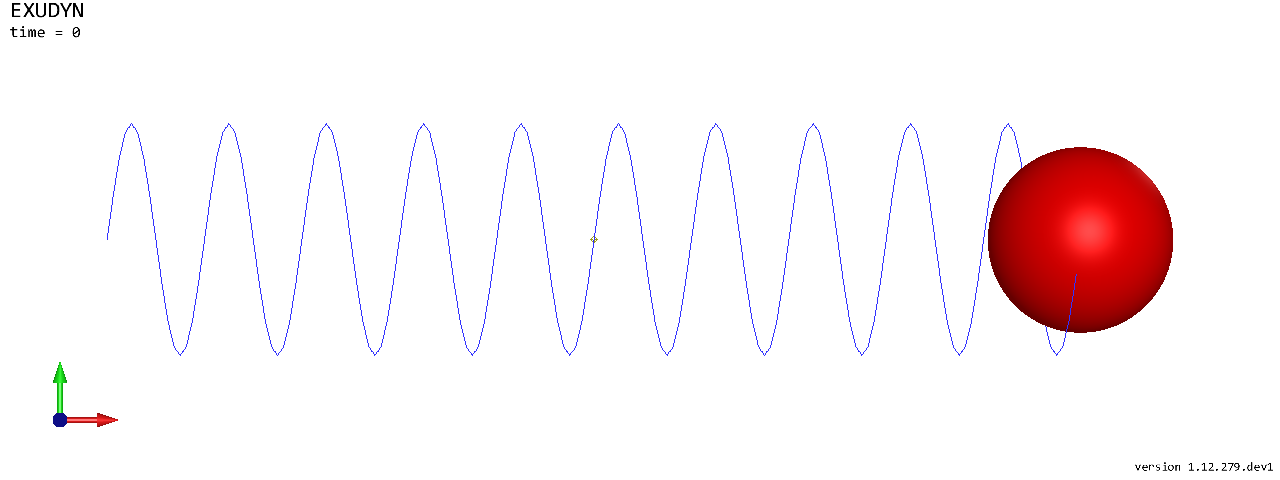

In [11]:
SC.visualizationSettings.general.showSolverInformation = False
SC.visualizationSettings.connectors.springNumberOfWindings = 10
image = ShowImage(SC, size=[1280,480])

We use time integration with a fixed step size and define the number of steps and the end time. All settings of a
simulation are in a structure given by `exu.SimulationSettings()`, which holds the default values; only the values
that differ need to be set. `verboseMode = 1` shows some solver output:

In [12]:
tEnd = 1     #end time of simulation
h = 0.001    #step size; leads to 1000 steps

simulationSettings = exu.SimulationSettings()
simulationSettings.solution.file.writePeriod = 5e-3      #output interval general
simulationSettings.solution.sensors.writePeriod = 5e-3   #output interval of sensors
simulationSettings.timeIntegration.numberOfSteps = int(tEnd/h)
simulationSettings.timeIntegration.endTime = tEnd
simulationSettings.timeIntegration.verboseMode = 1

We use the generalized-$\alpha$ solver, the default; its numerical damping is needed for index 3 constraints. With
only spring-dampers, the spectral radius can be 1 - no numerical damping:

In [13]:
simulationSettings.timeIntegration.generalizedAlpha.spectralRadius = 1
mbs.SolveDynamic(simulationSettings)

+++++++++++++++++++++++++++++++
EXUDYN V1.12.279.dev1 solver: implicit second order time integration
STEP1000, t = 1s, timeToGo = 0s, Nit/step = 1
Solver terminated successfully after 0.0012072 seconds.


True

The simulation takes a few milliseconds. The final (current) position of the node:

In [14]:
u = mbs.GetNodeOutput(n1, exu.OutputVariableType.Position)
print('displacement=', u)

displacement= [0.51183493 0.         0.        ]


The exact solution of the damped oscillator, $x(t) = e^{-\omega_0 D t}\left(C_1 \cos(\omega t) + C_2 \sin(\omega t)\right) + x_0$
with $\omega_0 = \sqrt{k/m}$, $D = d/(2\sqrt{k m})$ and $\omega = \omega_0\sqrt{1-D^2}$, as a matrix whose first
column is the time, as the sensors store their values:

In [15]:
omega0 = np.sqrt(spring/mass)          #eigen frequency of undamped system
dRel = damper/(2*np.sqrt(spring*mass)) #dimensionless damping
omega = omega0*np.sqrt(1-dRel**2)      #eigen freq of damped system
C1 = u0-x0                             #static solution needs to be considered!
C2 = (v0+omega0*dRel*C1) / omega       #C1, C2 are coeffs for solution
t = np.linspace(0, tEnd, int(tEnd/h)+1)
refSol = np.column_stack((t, np.exp(-omega0*dRel*t)*(C1*np.cos(omega*t)+C2*np.sin(omega*t))+x0))

`PlotSensor` plots sensors and such matrices: the exact and the numerical displacement, and the force of the
spring-damper in kN. The coordinates do not include the reference position (0.5 here), see
[coordinates](#sec-overview-items-coordinates):

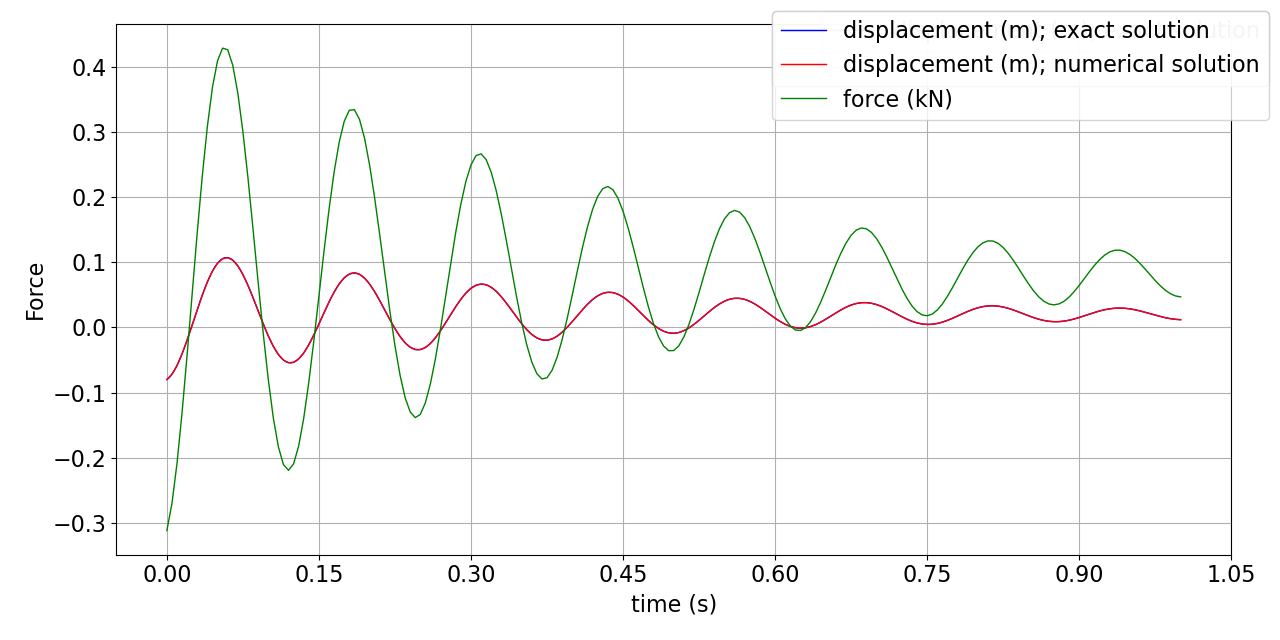

In [16]:
mbs.PlotSensor(sensorNumbers=[refSol], components=[0], labels=['displacement (m); exact solution'],
               colorCodeOffset=2, closeAll=True)
mbs.PlotSensor(sensorNumbers=[sDisp], components=[0], labels=['displacement (m); numerical solution'],
               colorCodeOffset=0, newFigure=False)
mbs.PlotSensor(sensorNumbers=[sForce], components=[0], labels=['force (kN)'], factors=[1e-3],
               colorCodeOffset=1, newFigure=False)

The whole solution was also written to `solution/coordinatesSolution.txt`; in a script, `mbs.SolutionViewer()`
shows it forward and backward in the render window.